<h1 style="text-align:center; color:green; font-size:48px;">
DHNx PROJECT - STEP 1
</h1>

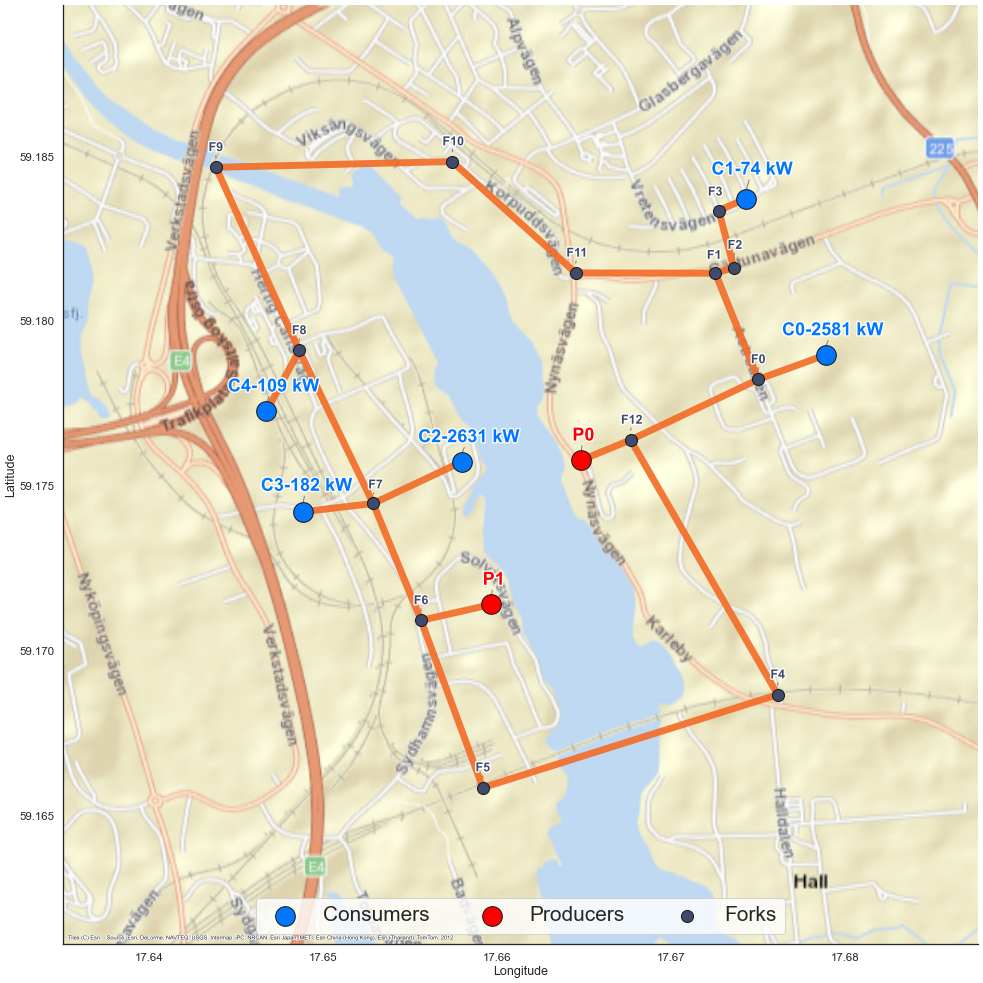

In [5]:
import matplotlib.pyplot as plt
import dhnx
import pandas as pd
import oemof.solph
from pyomo.environ import SolverFactory
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import contextily as ctx
from DHNx_gen_map import plot_dhn_map

network = dhnx.network.ThermalNetwork()
network = network.from_csv_folder(r"../2_inputs/1_step_twn_data")
invest_opt = dhnx.input_output.load_invest_options(r"../2_inputs/1_step_invest_data")

fig, ax = plot_dhn_map(network)
plt.show()


<h1 style="text-align:center; color:green; font-size:48px;">
OPTIMIZE THE NETWORK
</h1>

INFO:dhnx.optimization.optimization_models:Initialize the energy system
INFO:dhnx.optimization.optimization_models:Create oemof objects
INFO:dhnx.optimization.optimization_models:Producers, Consumers Nodes appended.


c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\oemof\solph\flows\_flow.py:163: FutureWarning: For backward compatibility, the option investment overwrites the option nominal_value. Both options cannot be set at the same time.
  warn(msg, FutureWarning)
c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\oemof\network\network\nodes.py:250: FutureWarning: Usage of oemof.network.Component is deprecated. Use oemof.network.Node instead.
  warnings.warn(
INFO:dhnx.optimization.optimization_models:DHS Nodes appended.
INFO:dhnx.optimization.optimization_models:Energysystem has been created
INFO:dhnx.optimization.optimization_models:Build the operational model
INFO:dhnx.optimization.optimization_models:Solve the optimization problem


Set parameter Username
Set parameter LicenseID to value 2729760
Academic license - for non-commercial use only - expires 2026-10-30
Read LP format model from file C:\Users\ardia\AppData\Local\Temp\tmpj2u8ro2l.pyomo.lp
Reading time = 0.03 seconds
x1: 614 rows, 530 columns, 1388 nonzeros
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) Ultra 7 155H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 614 rows, 530 columns and 1388 nonzeros
Model fingerprint: 0xac62b113
Variable types: 464 continuous, 66 integer (66 binary)
Coefficient statistics:
  Matrix range     [7e-04, 3e+03]
  Objective range  [4e+00, 1e+06]
  Bounds range     [1e+00, 3e+03]
  RHS range        [7e+01, 3e+03]
Presolve removed 476 rows and 344 columns
Presolve time: 0.00s
Presolved: 138 rows, 186 columns, 538 nonzeros
Variable types: 123 continuous, 63 integer (63 binary)
Fou

INFO:root:Optimization successful...


   from_node      to_node hp_type     capacity  direction          costs  \
id                                                                         
0   forks-12      forks-0  DN-150  2728.789249          1  689812.478537   
1    forks-0  consumers-0  DN-150  2597.930231          1  350084.553909   
2    forks-0      forks-1   DN-32    96.973811          1  304844.921904   
3    forks-1      forks-2   DN-32    84.703806          1   46582.994959   
4    forks-2      forks-3   DN-32    82.898571          1  155121.567539   
5    forks-3  consumers-1   DN-32    76.921560          1   77304.050227   
6    forks-1     forks-11    None     0.000000          0       0.000000   
7   forks-11     forks-10    None     0.000000          0       0.000000   
8   forks-10      forks-9    None     0.000000          0       0.000000   
9    forks-9      forks-8    None     0.000000          0       0.000000   
10   forks-8  consumers-4   DN-32   117.091562          1  189670.781780   
11   forks-8

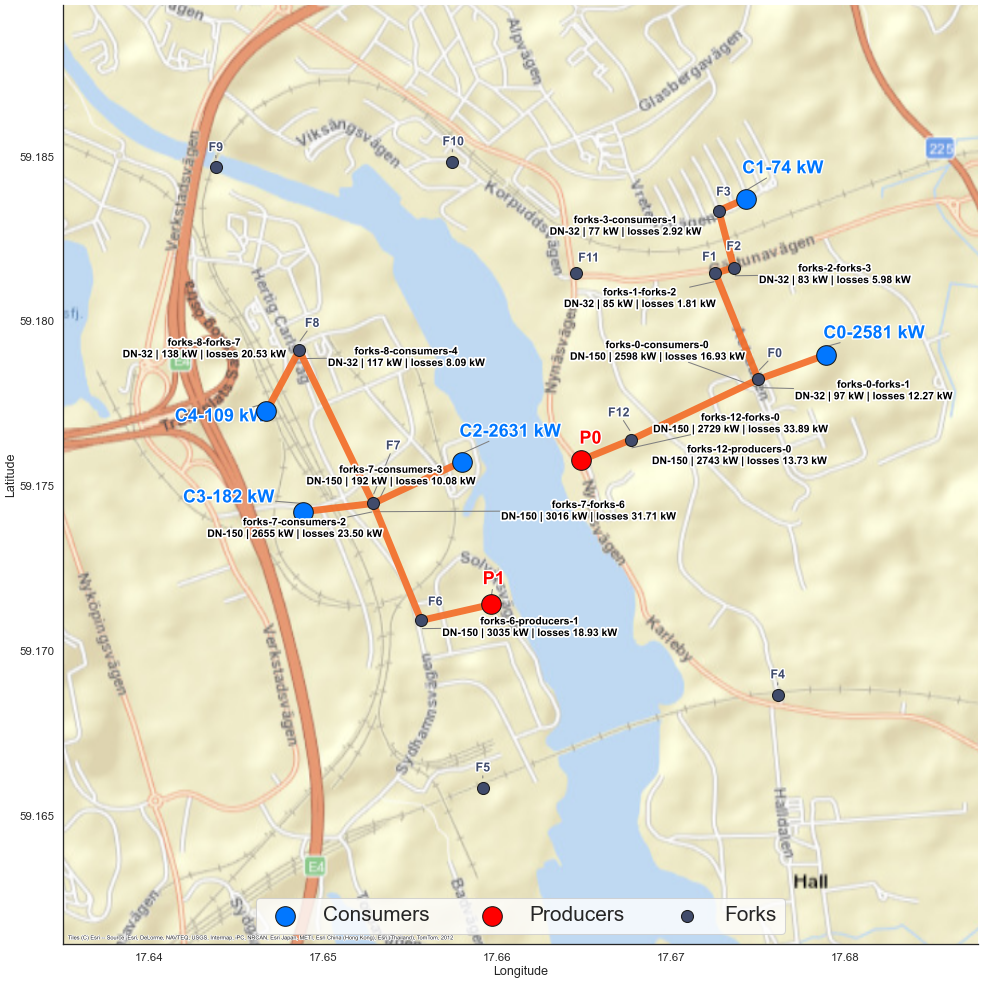

In [6]:
network.optimize_investment(invest_options=invest_opt,  solver='gurobi')
results_edges = network.results.optimization['components']['pipes']
print(results_edges[['from_node', 'to_node', 'hp_type', 'capacity',
                     'direction', 'costs', 'losses']])
results_edges.to_csv("../3_outputs/DHNx_step1_result.csv", index=True)

print('Objective value: ', network.results.optimization['oemof_meta']['objective'])

twn_results = network
twn_results.components['pipes'] = results_edges[results_edges['capacity'] > 0.001]
results_pipes = network.results.optimization['components']['pipes']
fig, ax = plot_dhn_map(network, results_edges=results_pipes, debug=True, figsize=(20,20),)

=== Pipe Segment Heat Loss Report ===
 id from_node     to_node  length hp_type    capacity         costs    losses  loss_percent
  1   forks-0 consumers-0     240  DN-150 2597.930231 350084.553909 16.930231      0.651681
  2   forks-0     forks-1     390   DN-32   96.973811 304844.921904 12.270005     12.652906
  3   forks-1     forks-2      60   DN-32   84.703806  46582.994959  1.805235      2.131232
  0  forks-12     forks-0     470  DN-150 2728.789249 689812.478537 33.885207      1.241767
 19  forks-12 producers-0     190  DN-150 2742.518493 279039.780170 13.729244      0.500607
  4   forks-2     forks-3     200   DN-32   82.898571 155121.567539  5.977011      7.210029
  5   forks-3 consumers-1     100   DN-32   76.921560  77304.050227  2.921560      3.798103
 14   forks-6 producers-1     250  DN-150 3034.840006 372184.073903 18.932405      0.623835
 12   forks-7 consumers-3     240  DN-150  192.075276 310370.624996 10.075276      5.245483
 13   forks-7     forks-6     420  DN-150 

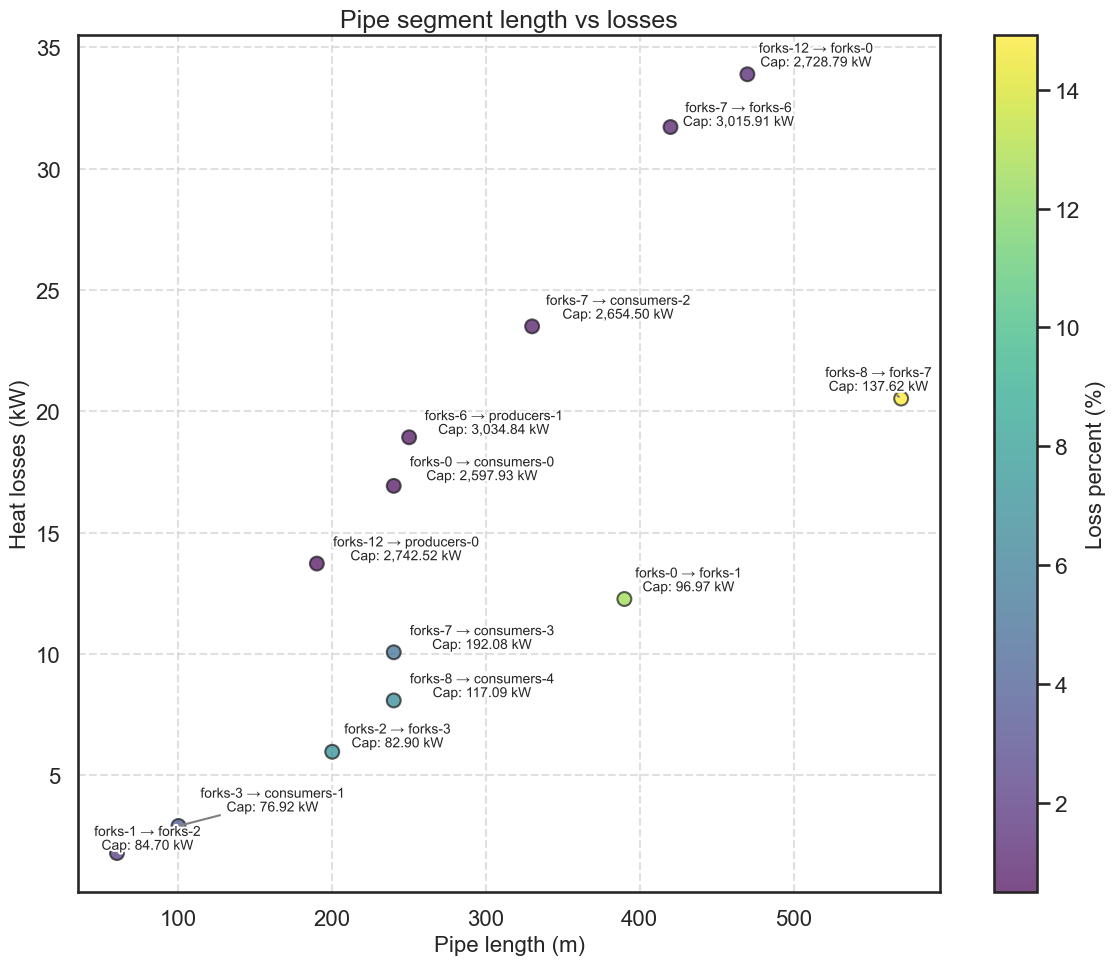

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from adjustText import adjust_text

def load_and_report_losses(csv_path):
    df = pd.read_csv(csv_path)

    # Ensure numeric
    df['losses'] = pd.to_numeric(df.get('losses', 0), errors='coerce').fillna(0)
    df['capacity'] = pd.to_numeric(df.get('capacity', 0), errors='coerce').fillna(0)

    # Compute loss percentage per segment safely
    df['loss_percent'] = df.apply(
        lambda row: (row['losses'] / row['capacity'] * 100) if row['capacity'] > 0 else np.nan,
        axis=1
    )

    # Filter only built & non-zero-loss segments
    df_losses = df[(df['capacity'] > 0) & (df['losses'] > 0)].copy()

    # Report table as before...
    df_report = df_losses[['id', 'from_node', 'to_node', 'length',
                           'hp_type', 'capacity', 'costs', 'losses', 'loss_percent']]
    df_report = df_report.sort_values('from_node', ascending=True)

    print("=== Pipe Segment Heat Loss Report ===")
    print(df_report.to_string(index=False))
    print("-------------------------------------")
    total_loss = df_losses['losses'].sum()
    mean_loss_percent = df_losses['loss_percent'].mean()
    print(f"Total heat loss (sum over segments)     : {total_loss:.2f} kW")
    print(f"Average loss percent (per segment)      : {mean_loss_percent:.2f}%")

    return df_losses, df_report

def load_and_plot_losses(csv_path):
    df = pd.read_csv(csv_path)
    df['losses'] = pd.to_numeric(df.get('losses', 0), errors='coerce').fillna(0)
    df['capacity'] = pd.to_numeric(df.get('capacity', 0), errors='coerce').fillna(0)

    df['loss_percent'] = df.apply(
        lambda r: (r['losses'] / r['capacity'] * 100) if r['capacity'] > 0 else np.nan,
        axis=1
    )

    df_losses = df[(df['capacity'] > 0) & (df['losses'] > 0)].copy()

    fig, ax = plt.subplots(figsize=(12, 10))
    sc = ax.scatter(df_losses['length'], df_losses['losses'],
                    c=df_losses['loss_percent'], cmap='viridis', edgecolor='k', s=100, alpha=0.7 )

    # Add colorbar
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Loss percent (%)', fontsize=16)
    # Annotate points
    texts = []
    for _, row in df_losses.iterrows():
        label = f"{row['from_node']} → {row['to_node']}\nCap: {row['capacity']:,.2f} kW"
        texts.append(
            ax.text(row['length'], row['losses'], label, fontsize=10, fontstyle='normal',
                    path_effects=[pe.withStroke(linewidth=3, foreground="white")])
        )

    adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray'))

    ax.set_xlabel('Pipe length (m)', fontsize=16)
    ax.set_ylabel('Heat losses (kW)', fontsize=16)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_title('Pipe segment length vs losses')
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    csv_path = "../3_outputs/DHNx_step1_result.csv"  # or your actual file
    df_losses, df_report = load_and_report_losses(csv_path)
    load_and_plot_losses(csv_path)
